# EXAMEN - Convocatoria 1 - Programación
Resolver el siguientes problemas de regresión lineal y clasificación.

## 1. Problema de Regresión lineal:

### 1.1. Generación de los datos:

Mediante la función `make_regressión` de sklearn, consultar su como emplearla para generar un conjunto de 2000 datos, 10 características, un ruido de 1 y fijar el parámetro ramdom_state=42.

In [142]:
# Vamos a trabajar con la libreria de sklearn. Realizaremos las importaciones necesarias.

from sklearn.datasets import make_regression
import pandas as pd

# Generamos el conjunto de datos especifico.
X, y = make_regression(
    n_samples=2000,    # 2000 datos
    n_features=10,     # 10 caracteristicas
    noise=1.0,         # Nivel de ruido
    random_state=42    # Semilla
)

# Comprobamos las dimensiones
print(f"Forma de X (Características): {X.shape}")
print(f"Forma de y (Variable objetivo): {y.shape}")

Forma de X (Características): (2000, 10)
Forma de y (Variable objetivo): (2000,)


### 1.2. Partición de datos externa.
Realizar una partición externa de tipo hold-out seleccionando un 20% de los datos para test (fijar una semilla en 42).

In [143]:
from sklearn.model_selection import train_test_split

# Realizamos la partición hold-out solicitada.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,   # Seleccionamos el 20% para el conjunto para test
    random_state=42   # Fijamos la semilla en 42 como se solicita.
)

# Verificamos que conjunto de test tenga el 20% de los datos.
print(f"Datos de entrenamiento (X_train): {X_train.shape[0]} filas")
print(f"Datos de prueba (X_test): {X_test.shape[0]} filas")

Datos de entrenamiento (X_train): 1600 filas
Datos de prueba (X_test): 400 filas


### 1.3. Estandarización de los datos de train y test.
Utilizar el método StandardScaler().

In [144]:
# Vamos a estandarizar los datos, para asegurarnos que cada uno de nuestros datos tengan el mismo peso y modelo pueda converger en menos iteracciones.
from sklearn.preprocessing import StandardScaler

# Inicializamos el metodo estandar scaler.
scaler = StandardScaler()

#Vamos a transformar los datos de entrenamiento por el momento.
X_train_scaled = scaler.fit_transform(X_train)

# A partir de lo que el scaler aprendio con los datos de entrenamiento, vamos a transformar los datos de prueba
X_test_scaled = scaler.transform(X_test)

print(f"Media de la característica 1 en X_train_scaled: {X_train_scaled[:, 0].mean():.4f}")
print(f"Desviación estándar de la característica 1 en X_train_scaled: {X_train_scaled[:, 0].std():.4f}")

Media de la característica 1 en X_train_scaled: 0.0000
Desviación estándar de la característica 1 en X_train_scaled: 1.0000


### 1.4. Creación de modelos e hiperparametrización mediante el método de sklearn GridSearchCV:

Instrucciones:

- Cree los siguientes modelos de regresión en un diccionario:
  - Regresión Lineal (OLS).
  - Regresión Lasso
  - Regresión Rígida
  - Vecinos más cercanos (KNN)

- Cree las siguiente métricas en un diccionario para evaluar:
  - MAE
  - MSE
  - RMSE
  - R2

- Haga una búsqueda de los siguientes hiperparámetros mediante GridSearchCV:

```
# Hiperparametros
parameters = {'OLS':{},
              'Lasso':{'alpha':(0.1,0.5,1,5,10,50,100)},
              'Ridge':{'alpha':(0.1,0.5,1,5,10,50,100)},
              'KNN':{'n_neighbors':np.arange(1,15),
                     'weights':('uniform','distance'),
                     'metric':('euclidean','manhattan','cosine')
                     }
              }
```

In [145]:
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Creamos de los modelos a utilizar.
models = {
    'OLS': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'KNN': KNeighborsRegressor()
}

# Creamos el diccionario de metricas para evaluar
metrics = {
    'MAE': mean_absolute_error,
    'MSE': mean_squared_error,
    'RMSE': lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    'R2': r2_score
}

# Hiperparámetros propuestos
parameters = {
    'OLS': {},
    'Lasso': {'alpha': (0.1, 0.5, 1, 5, 10, 50, 100)},
    'Ridge': {'alpha': (0.1, 0.5, 1, 5, 10, 50, 100)},
    'KNN': {
        'n_neighbors': np.arange(1, 15),
        'weights': ('uniform', 'distance'),
        'metric': ('euclidean', 'manhattan', 'cosine')
    }
}

# Búsqueda de hiperparámetros con GridSearchCV
best_models = {}

print("Iniciando la búsqueda de hiperparámetros...\n")

for name, model in models.items():
    print(f"Entrenando: {name}")

    # Configuramos el GridSearchCV
    # cv=5 lo utilizamos para determinar el numero de folds.
    grid = GridSearchCV(
        estimator=model,
        param_grid=parameters[name],
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1,
        refit="MAE"
    )

    # Ajustamos el modelo con los datos de entrenamiento escalados
    grid.fit(X_train_scaled, y_train)

    # Guardamos el mejor modelo encontrado
    best_models[name] = grid.best_estimator_

    # Imprimimos los resultados
    print(f"Mejores parámetros: {grid.best_params_}")
    print("-" * 50)

Iniciando la búsqueda de hiperparámetros...

Entrenando: OLS
Mejores parámetros: {}
--------------------------------------------------
Entrenando: Lasso
Mejores parámetros: {'alpha': 0.1}
--------------------------------------------------
Entrenando: Ridge
Mejores parámetros: {'alpha': 0.1}
--------------------------------------------------
Entrenando: KNN
Mejores parámetros: {'metric': 'cosine', 'n_neighbors': np.int64(14), 'weights': 'distance'}
--------------------------------------------------


### 1.5. Evaluación de los modelos sobre el conjunto de test.
- Entrenar los modelos anteriores utilizando todos los datos de entrenamiento y quédese con el mejor modelo de cada uno de los modelos de regresión arrojados por GridSearchCV. Es decir, debe tener un mejor modelo por cada regresión (OLS, Lasso, Rígida y KNN)
- Evaluar su rendimiento sobre el conjunto de test mostrando para cada uno de los modelos

,Modelo,MAE,MSE,RMSE,R2
0,OLS,0.7731,0.9534,0.9764,1.000
1,Lasso,0.8031,1.0349,1.0173,1.000
2,Ridge,0.7727,0.9524,0.9759,1.000
3,KNN,50.0401,4579.8916,67.6749,0.872


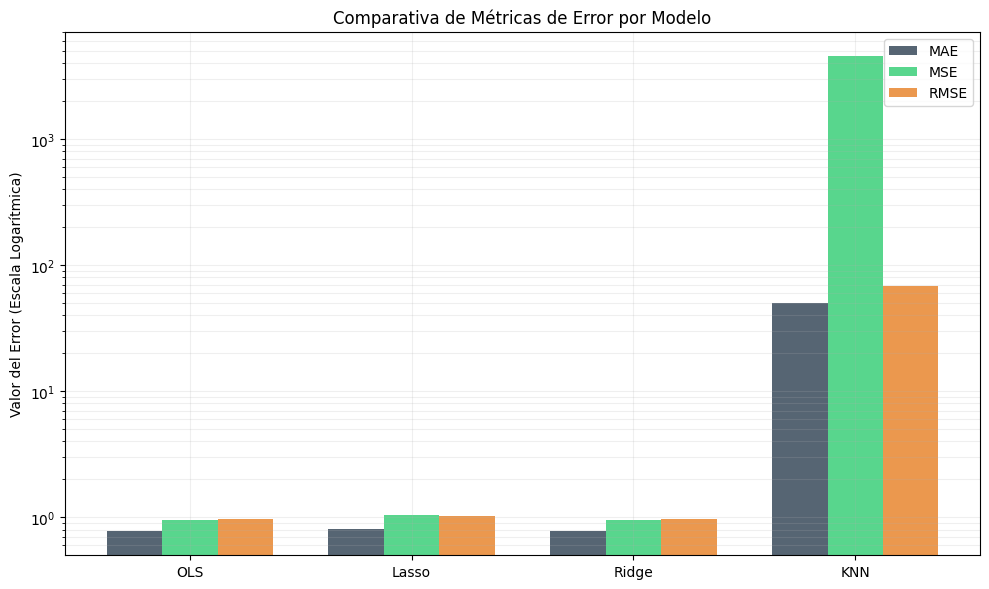

In [146]:
# Ahora vamos a evaluar los modelos sobre el conjunto de test.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

result_below_test = []
models_arr = []
mae_arr = []
mse_arr = []
rmse_arr = []
r2_arr = []

for name, grid_model in best_models.items():

  y_pred = grid_model.predict(X_test_scaled) # Predecimos sobre el conjunto de datos de test.

  # Calculamos las métricas una sola vez por cada modelo
  mae = round(mean_absolute_error(y_test, y_pred), 4)
  mse = round(mean_squared_error(y_test, y_pred), 4)
  rmse = round(np.sqrt(mse),4)
  r2 = round(r2_score(y_test, y_pred),4)

  result_below_test.append({
      'Modelo': name,
      'MAE': mae,
      'MSE': mse,
      'RMSE': rmse,
      'R2': r2
  })
  models_arr.append(name)
  mae_arr.append(mae)
  mse_arr.append(mse)
  rmse_arr.append(rmse)
  r2_arr.append(r2)

final_error_results = pd.DataFrame(result_below_test)

display(final_error_results)
print()
### ----------------- Graficamos los resultados ------------- ###

import matplotlib.pyplot as plt

n_modelos_reg = np.arange(len(models_arr))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(n_modelos_reg - width, mae_arr, width, label='MAE', color='#2c3e50', alpha=0.8)
ax.bar(n_modelos_reg, mse_arr, width, label='MSE', color='#2ecc71', alpha=0.8)
ax.bar(n_modelos_reg + width, rmse_arr, width, label='RMSE', color='#e67e22', alpha=0.8)

ax.set_yscale('log')

ax.set_ylabel('Valor del Error (Escala Logarítmica)')
ax.set_title('Comparativa de Métricas de Error por Modelo')
ax.set_xticks(n_modelos_reg)
ax.set_xticklabels(models_arr)
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

### 1.6. Interpretación de resultados.
* Justifica cuál de los modelos utilizarías para ponerlo en producción

Basandonos en los resultados obtenidos, podemos notar que el modelo que tiene una magnitud de error mas baja observando las metricas (MAE, MSE y RMSE) es el modelo *Ridge* el cual elegiremos.

Sabemos que para seleccionar un modelo, uno de objetivos principales a analizar es que el error encontrado este mas cercano a 0, lo cual indica que en las prediciones que haga nuestro modelo tendremos una magnitud de error menor.

Asi mismo, notamos que la diferencia con el modelo OLS es infima, sin embargo, a nivel matematico el modelo de Rigde es superior a OLS, debido a que, el inconveniente que tiene modelo OLS es que si tenemos muchas variables o si alguna de ellas esta muy correlacionadas los coeficientes de la formula matematica pueden crecer haciendo que el modelo sea inestable.

Consideremos que el modelo OLS esta basado en la siguiente funcion de coste:
$$J_{OLS}(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Donde:

* $y_i$ es el valor real.

* $\hat{y}_i$ es la predicción del modelo.

* $\beta$ representa los coeficientes del modelo.

Y ademas tiene en cuenta que $\hat{y}_i$ esta denotada por:

$$\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip}
$$Donde:

* $\beta_0$ es el intercepto (el valor estimado cuando todas las variables son cero).

* $\beta_1, \beta_2, \dots, \beta_p$ son los coeficientes que el modelo está intentando aprender y optimizar.

* $x_{i1}, x_{i2}, \dots, x_{ip}$ son los valores numéricos de las características (columnas) para esa fila $i$.

Entonces, basado en ello, si tenemos muchas variables entonces los coeficientes $\beta$ podrian ser problematicos haciendo _el modelo mas inestable y sensible a datos nuevos_ que el modelo de Rigde.

Tengamos en cuenta que el modelo de rigde esta regido por la siguiente expresion,

$$J_{Ridge}(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

Donde:
* El primer término es exactamente el mismo error de OLS.

* El segundo término es la penalización: la suma de los coeficientes al cuadrado multiplicada por $\alpha$.

* $p$ es el número total de variables predictoras.

Podemos observar que las formulas entre OLS y Ridge son muy similares, sin embargo, el modelo de Rigde modifica la funcion de costo original y le agrega un termino de penalizacion, que en terminos matematicos quiere decir _Regularizacion (L2)_.

Entonces al observar la ecuacion de Ridge podemos explicar matematicamente porque supera a OLS, y aunque sea por un margen pequeño en terminos de resultados, el modelo de Rigde se posiciona como un modelo mas conservador, generalizable y protegido contra la varianza alta en los coeficientes.

Me parecio un poco curioso ver el valor de $R^2$ con 1.000, por lo que investigue un poco sobre la razon de porque estaria dando un valor demasiado "perfecto", analizando un poco es posible que hubiese una fuga de datos en la fase de preparacion o modelado, por lo que antes de pasarlo a produccion podriamos realizar una doble validacion sobre las variables predictoras para determinar su eficiencia y capacidad de generalizacion con datos nuevos.

## 2. Problema de Clasificación con generación de datos sintéticos y selección de características

En esta actividad se trabajará con generación de datos sintéticos para problemas de clasificación utilizando la función `make_classification` de la librería **scikit-learn**.

El objetivo es evaluar si distintos métodos de selección de características y modelos de clasificación son capaces de identificar las variables realmente relevantes dentro de un conjunto de datos generado artificialmente.

### 2.1 Importación de librerías

Importe las siguientes librerías:

In [147]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.preprocessing import StandardScaler

### 2.2. Generación del conjunto de datos

2.2.1. Utilice `make_classification` para generar un dataset de clasificación binaria.

Debe definir explícitamente los siguientes parámetros:

- `n_samples`
- `n_features`
- `n_informative`
- `n_redundant`

El dataset debe tener:

- al menos **500 observaciones**
- al menos **10 características**

El objetivo es que existan variables:

- **informativas**
- **redundantes**
- **no informativas**



In [148]:
# Vamos a generar el dataset:
# Definición de parámetros
n_samples = 1000
n_features = 12
n_informative = 4
n_redundant = 3

# Generación del dataset sintético
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_informative,
    n_redundant=n_redundant,
    n_classes=2,         # Clasificación binaria
    random_state=42      # Semilla
)

# Convertir a DataFrame para mejor visualización
columns = [f"Feature_{i}" for i in range(1, n_features + 1)]
df_X = pd.DataFrame(X, columns=columns)
df_y = pd.Series(y, name="Target")

print(f"Dimensiones de las características (X): {df_X.shape}")
print(f"Dimensiones de la variable objetivo (y): {df_y.shape}")

Dimensiones de las características (X): (1000, 12)
Dimensiones de la variable objetivo (y): (1000,)


2.2.2. Explique brevemente los valores elegidos para cada parámetro.

* n_samples = 1000: Para el numero de ejemplos para el problema se menciona utilizar mas de 500, sin embargo, quisimos tener el doble de este valor para asegurar tener mas datos para aprender y no caer en sobreajuste o subajuste.

* n_features = 12: Elegimos 12 caracteristicas sobre las 10 requeridas para tener mayor cantidad de mezcla.

* n_informative = 4: Uso 4 debido a que estas representan las variables que contienen la señal matematica para predecir la clase.

* n_redundant = 3: Son combinaciones lineales de las variables informativas. Se incluyen (3) porque es necesario verificar si los algoritmos de seleccion de caracteristicas son capaces de lidiar con la multicolinealidad.

Nota. La funcion _make_classification_ automatizamente rellena el resto de las caracteristicas con ruido aleatorio.

### 2.3. División de los datos.

Divida el dataset en:

- **conjunto de entrenamiento**
- **conjunto de prueba**

El conjunto de entrenamiento se utilizará para:

- selección de características
- búsqueda de hiperparámetros
- entrenamiento de los modelos

El conjunto de prueba se utilizará **únicamente para evaluar el desempeño final de los modelos**.

In [149]:
# Vamos a subdividir nuestro data set en entrenamiento y test.

# Dividimos los datos (80% para entrenamiento, 20% para prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # Dejamos el 20% de los datos para la validacion final
    random_state=42,     # Semilla
    stratify=y           # Mantiene la proporción de clases
)

# Nota. Se agrega el parametro stratify=y para problemas de clasificacion
# se recomienda hacer, debido a que garantiza que la proporcion de la clase 0 y 1,
# se mantenga si en X_train y X_test.

print("--- División del Dataset Clasificacion ---")
print(f"Entrenamiento (X_train): {X_train.shape[0]} observaciones para entrenar, seleccionar y optimizar.")
print(f"Prueba (X_test): {X_test.shape[0]} observaciones guardadas para la evaluación final.")

--- División del Dataset Clasificacion ---
Entrenamiento (X_train): 800 observaciones para entrenar, seleccionar y optimizar.
Prueba (X_test): 200 observaciones guardadas para la evaluación final.


### 2.4. Selección de caractarística

Aplique un método de selección de características para identificar cuáles variables parecen ser más relevantes para la predicción.

Puede utilizar el método **SelectKBest** de `sklearn.feature_selection`. Este método evalúa cada característica de forma individual mediante una medida estadística y selecciona las **k variables con mayor puntuación**, es decir, aquellas que tienen mayor relación con la variable objetivo.

Utilice como función de puntuación `f_classif`.

Compare las características seleccionadas con las definidas como **informativas** en `make_classification` y discuta si el método logra identificarlas correctamente.

In [150]:
from IPython.display import display

# Vamos a configurar k=7 (intentaremos capturar las 4 informativas + las 3 redundantes)
k_optimal = 7

chooser = SelectKBest(score_func=f_classif, k=k_optimal)

# Ajustamos el selector unicamente con X_train para evitar fuga de datos
chooser.fit(X_train, y_train)

# Extraemos las puntuaciones calculadas por f_classif
scores = chooser.scores_

# Obtenemos un array indicando cuales fueron seleccionadas
columns_selected = chooser.get_support()

# Armamos un DataFrame para la visualizacion
df_scores = pd.DataFrame({
    'Característica': df_X.columns,
    'Puntuación (ANOVA)': np.round(scores, 4),
    'Seleccionada': columns_selected
})

# Ordenamos de mayor a menor puntuacion
df_scores_sorted = df_scores.sort_values(by='Puntuación (ANOVA)', ascending=False)

print("----------- Ranking de Características --------------")

display(df_scores_sorted)

----------- Ranking de Características --------------


,Característica,Puntuación (ANOVA),Seleccionada
0,Feature_1,127.5508,True
8,Feature_9,123.0598,True
6,Feature_7,21.8956,True
11,Feature_12,1.9026,True
2,Feature_3,1.5557,True
5,Feature_6,0.9417,True
4,Feature_5,0.3093,True
9,Feature_10,0.2889,False
1,Feature_2,0.2767,False
7,Feature_8,0.2378,False




---


*Nota.* Para el apartado anterior realizamos un analisis de varianza ANOVA, recordemos que este analisis nos permite evaluar la relacion lineal de cada variable respecto a la variable objetivo. Cabe mencionar que entre mayor sea el valor de puntuacion, mas importante es la variable.


---



## 2.5. Escalado de datos

Antes de entrenar los modelos, estandarice las variables utilizando **StandardScaler** de `sklearn.preprocessing`.

La estandarización consiste en transformar las variables para que tengan:

- media igual a 0
- desviación estándar igual a 1

Este paso es importante para modelos sensibles a la escala de los datos, como **regresión logística** y **SVM**. Los árboles de decisiones, son independientes del escalado.

El escalado debe realizarse de la siguiente manera:

1. Ajustar el `StandardScaler` **únicamente con el conjunto de entrenamiento**.
2. Aplicar esa transformación tanto al conjunto de entrenamiento como al conjunto de prueba.


In [151]:
# Vamos a entrenar el modelo con los datos de entrenamiento,
# escalamos, y transformamos.

scaler_classification = StandardScaler()

# Aplicacmos el metodo fit_transform, para que el escalador pueda
# aprender la media y la desviacion del conjunto X_train y transformamos los datos.
X_train_scaled_array = scaler_classification.fit_transform(X_train)

# Ahora vamos al conjunto de datos X_test, pero ojo el detalle, en esta
# oportunidad solo transformamos los datos con el escalador. No vamos a permitir que
# El modelo aprenda sobre estos datos.
X_test_scaled_array = scaler_classification.transform(X_test)

name_columns = [f"Feature_{i}" for i in range(1, X_train.shape[1] + 1)]

# Vamos a crear un par de dataframes para visualizacion,
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=name_columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=name_columns)

print(f"Media de la primera variable en Train:  {X_train_scaled.iloc[:, 0].mean():.4f}")
print(f"Desviación estándar de la primera variable en Train: {X_train_scaled.iloc[:, 0].std():.4f}")

Media de la primera variable en Train:  -0.0000
Desviación estándar de la primera variable en Train: 1.0006




---


*Nota*. Observamos en la media un valor negativo, con esto confirmamos que el escalado funciono correctamente debido a que el valor de la media de la primera variable es un valor super bajo cercano a 0.

---



### 2.6. Modelos e hiperparametrización

Trabaje con los siguientes modelos.

**Modelos obligatorios**

- Árbol de decisión (`DecisionTreeClassifier`)
- Regresión logística (`LogisticRegression`)

**Modelo bonus**

- Máquina de soporte vectorial (`SVC`)

Para cada modelo, realice una búsqueda de hiperparámetros utilizando **GridSearchCV** sobre el **conjunto de entrenamiento**.

Utilice las siguientes listas de hiperparámetros:

**Árbol de decisión**

- `max_depth`: [3, 5, 10, None]
- `min_samples_split`: [2, 5, 10]
- `criterion`: ["gini", "entropy"]

**Regresión logística**

- `C`: [0.01, 0.1, 1, 10]
- `solver`: ["lbfgs", "liblinear"]

**SVM (bonus)**

- `C`: [0.1, 1, 10]
- `kernel`: ["linear", "rbf"]
- `gamma`: ["scale", "auto"]

Utilice validación cruzada dentro de `GridSearchCV` para determinar la mejor combinación de hiperparámetros.


In [152]:
# Definimos los modelos solicitados
algorithms = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'SVC': SVC(random_state=42, probability=True)
}

# Definimos los hiperparametros por modelo
parameters = {
    'DecisionTree': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ["gini", "entropy"]
    },
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ["lbfgs", "liblinear"]
    },
    'SVC': {
        'C': [0.1, 1, 10],
        'kernel': ["linear", "rbf"],
        'gamma': ["scale", "auto"]
    }
}

# Entrenamos con GridSearchCV
best_models = {}

for name in algorithms:
    print(f"Entrenando y optimizando con datos de Train: {name}...")

    grid_search = GridSearchCV(
        estimator=algorithms[name],
        param_grid=parameters[name],
        cv=5,            # Validación cruzada de 5 folds
        scoring='accuracy', # Metrica principal para clasificación
        n_jobs=-1,
        return_train_score=True
    )

    # Ajustamos usando los datos escalados
    grid_search.fit(X_train_scaled, y_train)

    # Guardamos el mejor modelo encontrado
    best_models[name] = grid_search

    print(f"Mejor combinacion para {name}: {grid_search.best_params_}")
    print(f"Mejor Accuracy en CV: {grid_search.best_score_:.4f}\n")

Entrenando y optimizando con datos de Train: DecisionTree...
Mejor combinacion para DecisionTree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Mejor Accuracy en CV: 0.8938

Entrenando y optimizando con datos de Train: LogisticRegression...
Mejor combinacion para LogisticRegression: {'C': 0.1, 'solver': 'lbfgs'}
Mejor Accuracy en CV: 0.6887

Entrenando y optimizando con datos de Train: SVC...
Mejor combinacion para SVC: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Mejor Accuracy en CV: 0.9062



### 2.7. Evaluación y análisis

Para cada modelo:

- Del punto anterior, obtenga el modelo con **los mejores hiperparámetros**.
- Evalúe el modelo final en el **conjunto de prueba**.
- Realice este proceso en dos escenarios:
  - utilizando **todas las características**
  - utilizando **solo las características seleccionadas**
- Compare los resultados utilizando métricas de clasificación apropiada y discuta:
  - si la selección de características mejora el desempeño del modelo
  - si reduce la complejidad del modelo
  - si permite identificar correctamente las variables informativas generadas en el dataset
  - qué modelo obtiene mejor desempeño después del ajuste de hiperparámetros


--- Comparativa Final De Desempeño Basado En Datos De Test ---


Modelo,Accuracy (Todas),Accuracy (Seleccionadas),F1-Score (Todas),F1-Score (Seleccionadas),Diferencia Accuracy
DecisionTree,0.9000,0.8150,0.8980,0.8122,0.0850
LogisticRegression,0.6700,0.6350,0.6733,0.6368,0.0350
SVC,0.9000,0.8500,0.8990,0.8421,0.0500


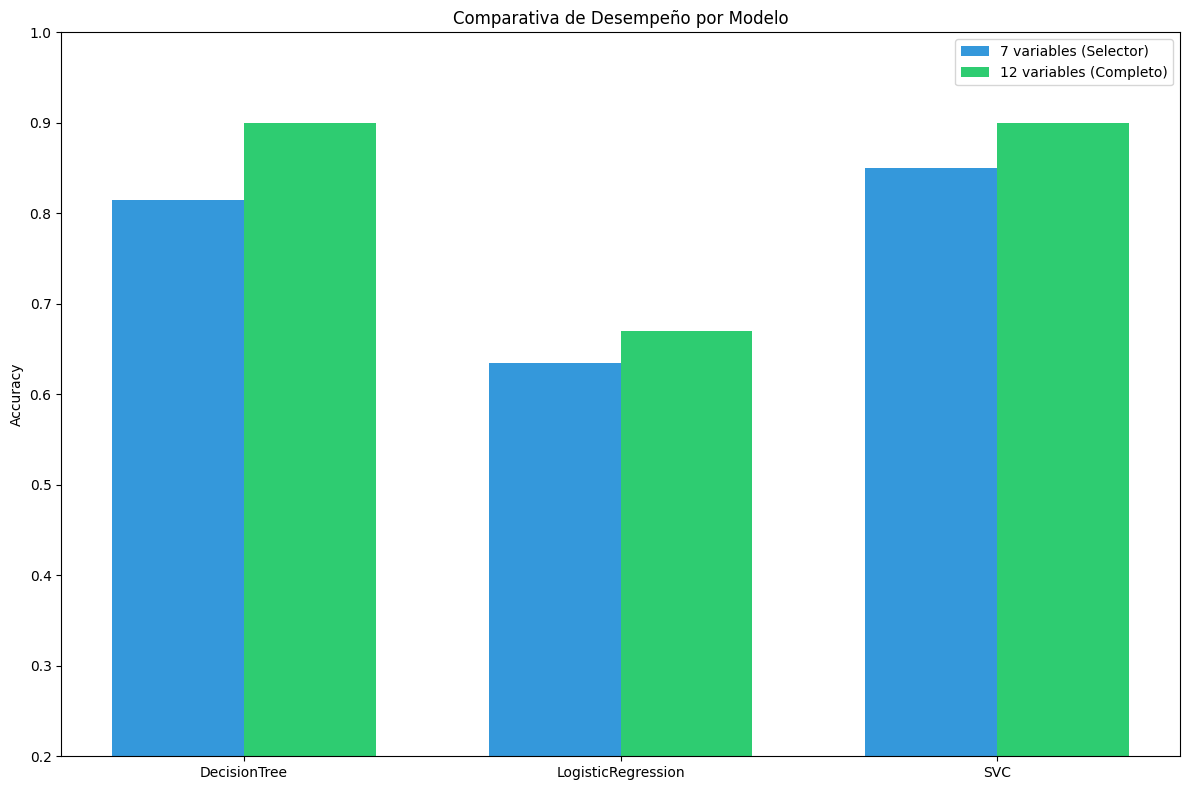

In [153]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.base import clone

# Instanciamos el selector con los datos escalados
chooser = SelectKBest(score_func=f_classif, k=7)
chooser.fit(X_train_scaled, y_train)

# Definir las variables seleccionadas previamente por SelectKBest
index_selected = chooser.get_support(indices=True)
X_train_reduced = X_train_scaled.iloc[:, index_selected]
X_test_reduced = X_test_scaled.iloc[:, index_selected]

results = []
name_models_arr = []
accuracy_feature_selected_arr = []
accuracy_all_feature_arr = []

for name, grid in best_models.items():
    # Obtenemos el mejor estimador del GridSearchCV
    model_all_features = grid.best_estimator_

    # --- Escenario 1: Evaluamos todas las caracteristicas ---
    y_pred_all_features = model_all_features.predict(X_test_scaled)
    accuracy_all_features = accuracy_score(y_test, y_pred_all_features)
    f1_all_features = f1_score(y_test, y_pred_all_features)

    # --- Escenario 2: Evaluamos caracteristicas seleccionadas ---
    model_selected_features = clone(model_all_features)

    model_selected_features.fit(X_train_reduced, y_train)
    y_pred_selected = model_selected_features.predict(X_test_reduced)
    accuracy_features_selected = accuracy_score(y_test, y_pred_selected)
    f1_selected = f1_score(y_test, y_pred_selected)

    results.append({
        'Modelo': name,
        'Accuracy (Todas)': accuracy_all_features,
        'Accuracy (Seleccionadas)': accuracy_features_selected,
        'F1-Score (Todas)': f1_all_features,
        'F1-Score (Seleccionadas)': f1_selected,
        'Diferencia Accuracy': abs(accuracy_features_selected - accuracy_all_features)
    })
    name_models_arr.append(name)
    accuracy_feature_selected_arr.append(accuracy_features_selected)
    accuracy_all_feature_arr.append(accuracy_all_features)

# Crear DataFrame de resultados
df_comparative = pd.DataFrame(results)

# Estilizar la tabla para el taller
style_table = df_comparative.style \
    .hide(axis="index") \
    .highlight_max(subset=['Accuracy (Seleccionadas)', 'F1-Score (Seleccionadas)'], color='green') \
    .format(precision=4)

print("--- Comparativa Final De Desempeño Basado En Datos De Test ---")
display(style_table)
print()
### ---------------------------- ###

# Graficamos los resultados:
import matplotlib.pyplot as plt

n_models = np.arange(len(name_models_arr))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(n_models - width/2, accuracy_feature_selected_arr, width, label='7 variables (Selector)', color='#3498db')
rects2 = ax.bar(n_models + width/2, accuracy_all_feature_arr, width, label='12 variables (Completo)', color='#2ecc71')

ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de Desempeño por Modelo')
ax.set_xticks(n_models)
ax.set_xticklabels(name_models_arr)
ax.set_ylim(0.2, 1.0)
ax.legend()

plt.tight_layout()
plt.show()


---
### Conclusiones Finales

#### ¿La selección de características mejora el desempeño del modelo?

En este experimiento que hemos realizado con datos sinteticos, podemos observar que el F1-Score y Accuracy disminuyeron ligeramente al pasar del modelo completo (12 variables) al modelo reducido (7 variables seleccionadas). Esto entonces nos indica que la seleccion no mejoro el desempeño predictivo.

#### ¿Reduce la complejidad del modelo?

Si logramos disminuir la complejidad del modelo, debido a que pasamos de las 12 variables originales a solo las 7 seleccionadas por el metodo _SelectKBest_, realizando este ajuste logramos reducir la cantidad de informacion que el modelo debe procesar de forma matematica. Esto se traduce en arboles de decision con menos ramas, en los modelos de regresion logistica y SVC con menos coeficientes y pesos por calcular, si analizamos un poco los numeros obtenidos, asumir una pérdida perdida de Accuracy a cambio de un modelo menos complejo a nivel computacional suena quiza a un beneificio, ya que resulta mas rapido de predecir y menos propenso al sobreajuste.

#### ¿Permite identificar correctamente las variables informativas?

El metodo estadistico que utilizamos (_SelectKBest_) y utilizando la prueba Anova con _f_classif_ se demostro ser altamente efectivo para separar la "señal" del "ruido". Luego de realizar este analisis pudimos encontrar las mejores 7 caracteristicas (4 informativas + 3 redundantes) y organizarlas de mayor a menor respecto a ANOVA, logrando asi descartar las 5 variables que fueron generadas puramente como ruido aleatorio al crear el data set.

#### ¿Qué modelo obtiene mejor desempeño?

El modelo muestra un mejor desempeño es la Máquina de Soporte Vectorial (SVC), logro mantener la estabilidad y los puntajes mas altos tanto en el escenario con todas las caracteristicas, como con el escenario reducido con las caracteristicas seleccionadas. Esto se debio a que el algoritmo SVC es bueno trazando fronteras de decision complejas en espacios multidimensionales superando asi las dificultadas lineales de la regresion logistica y demostrando ser mas robusto (en este caso) frente al sobre ajuste que el modelo de arboles de decision.


---